First 5 rows of dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  

Explained Variance Ratio:
[0.72962445 0.22850762]

PCA Transformed Data:
        PC1       PC2  target
0 -2.264703  0.480027       0
1 -2.080961 -0.674134       0
2 -2.364229 -0.341908       0
3 -2.299384 -0.597395       0
4 -2.389842  0.646835       0


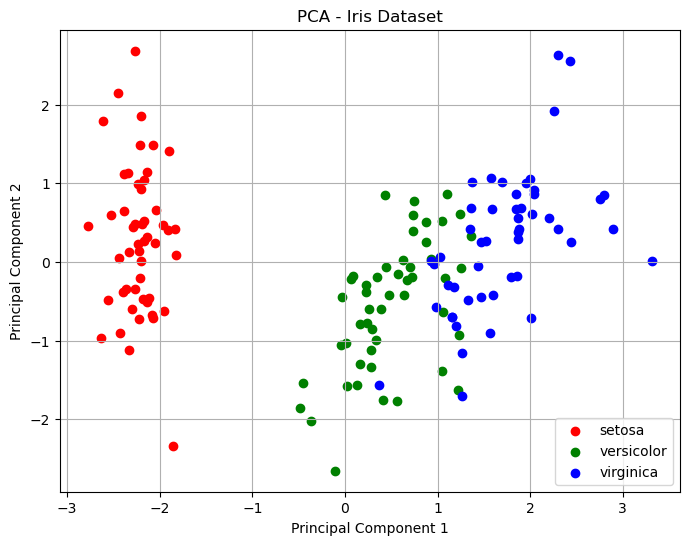

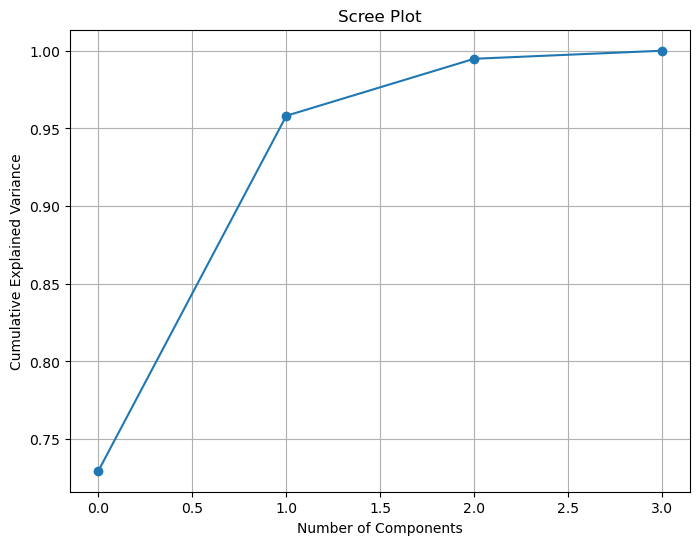

In [1]:
# ==============================
# PCA IMPLEMENTATION (FULL CODE)
# ==============================

# 1. Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


# 2. Load Dataset
iris = load_iris()

# Create DataFrame
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target

print("First 5 rows of dataset:")
print(df.head())


# 3. Separate Features and Target
X = df.drop('target', axis=1)
y = df['target']


# 4. Standardize the Data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# 5. Apply PCA (reduce to 2 components)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)


# 6. Create PCA DataFrame
pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
pca_df['target'] = y

print("\nPCA Transformed Data:")
print(pca_df.head())


# 7. Visualize PCA Result
plt.figure(figsize=(8,6))

colors = ['red', 'green', 'blue']
labels = iris.target_names

for i in range(len(labels)):
    plt.scatter(
        pca_df[pca_df['target'] == i]['PC1'],
        pca_df[pca_df['target'] == i]['PC2'],
        color=colors[i],
        label=labels[i]
    )

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA - Iris Dataset')
plt.legend()
plt.grid()
plt.show()


# 8. Scree Plot (Explained Variance)
pca_full = PCA()
pca_full.fit(X_scaled)

plt.figure(figsize=(8,6))
plt.plot(np.cumsum(pca_full.explained_variance_ratio_), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Scree Plot')
plt.grid()
plt.show()

In [2]:
# ==============================
# PCA ON ENERGY EFFICIENCY DATASET
# ==============================

# 1. Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


# 2. Load Dataset
# Make sure the file is in the same folder
df = pd.read_excel("ENB2012_data.xlsx")

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nFirst 5 rows:")
print(df.head())


# 3. Rename Columns (for simplicity)
df.columns = [
    'Relative_Compactness',
    'Surface_Area',
    'Wall_Area',
    'Roof_Area',
    'Overall_Height',
    'Orientation',
    'Glazing_Area',
    'Glazing_Area_Distribution',
    'Heating_Load',
    'Cooling_Load'
]


# 4. Select Features (exclude target variables)
X = df.drop(['Heating_Load', 'Cooling_Load'], axis=1)


# 5. Standardize the Data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# 6. Apply PCA (2 components)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)
print("Total Variance Retained:", sum(pca.explained_variance_ratio_))


# 7. Convert to DataFrame
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])


# 8. Visualization
plt.figure(figsize=(8,6))
plt.scatter(pca_df['PC1'], pca_df['PC2'], c='blue', alpha=0.6)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA - Energy Efficiency Dataset')
plt.grid()
plt.show()


# 9. Scree Plot (Explained Variance)
pca_full = PCA()
pca_full.fit(X_scaled)

plt.figure(figsize=(8,6))
plt.plot(np.cumsum(pca_full.explained_variance_ratio_), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Scree Plot - Energy Dataset')
plt.grid()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'ENB2012_data.xlsx'

Dataset Shape: (569, 31)

First 5 rows:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst

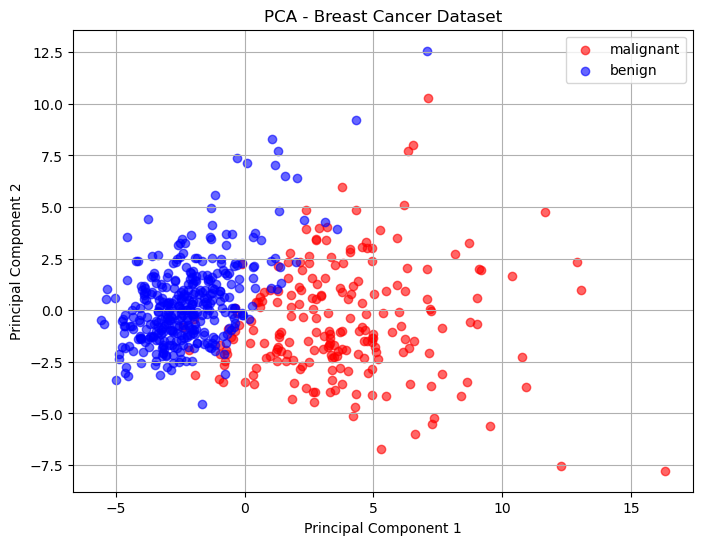

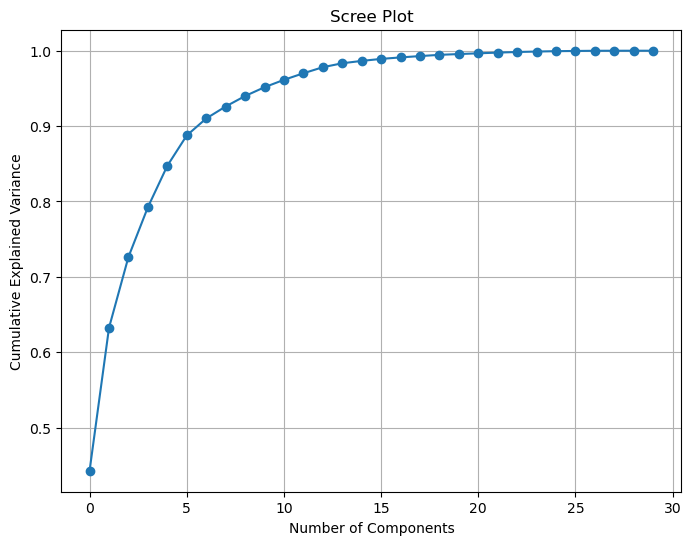

In [3]:
# ==============================
# PCA USING BUILT-IN DATASET
# Breast Cancer Dataset
# ==============================

# 1. Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


# 2. Load Dataset (NO FILE NEEDED ✅)
data = load_breast_cancer()

# Create DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())


# 3. Separate Features and Target
X = df.drop('target', axis=1)
y = df['target']


# 4. Standardize the Data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# 5. Apply PCA (reduce to 2 components)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)
print("Total Variance Retained:", sum(pca.explained_variance_ratio_))


# 6. Convert to DataFrame
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['target'] = y


# 7. Visualization
plt.figure(figsize=(8,6))

colors = ['red', 'blue']
labels = data.target_names

for i in range(2):
    plt.scatter(
        pca_df[pca_df['target'] == i]['PC1'],
        pca_df[pca_df['target'] == i]['PC2'],
        color=colors[i],
        label=labels[i],
        alpha=0.6
    )

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA - Breast Cancer Dataset')
plt.legend()
plt.grid()
plt.show()


# 8. Scree Plot (Variance Explained)
pca_full = PCA()
pca_full.fit(X_scaled)

plt.figure(figsize=(8,6))
plt.plot(np.cumsum(pca_full.explained_variance_ratio_), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Scree Plot')
plt.grid()
plt.show()